<a href="https://colab.research.google.com/github/ShashankSatishkumar/NNDLQHOproject/blob/main/nndl_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting training...
Epoch    0 | Loss: 2.49961 | Estimated Energy: 1.01000
Epoch  500 | Loss: 0.00318 | Estimated Energy: 0.62639
Epoch 1000 | Loss: 0.00007 | Estimated Energy: 0.50249
Epoch 1500 | Loss: 0.00005 | Estimated Energy: 0.50004

Final Estimated Ground State Energy: 0.50002 (True Value: 0.5)


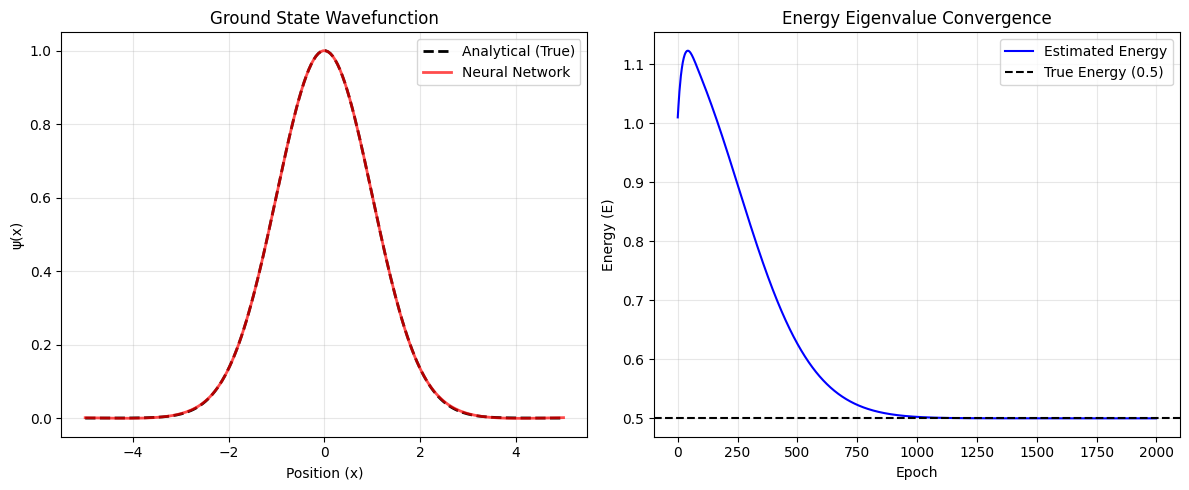

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np


torch.manual_seed(42)


class QHONetwork(nn.Module):
    def __init__(self):
        super(QHONetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.E = nn.Parameter(torch.tensor([1.0]))

    def forward(self, x):
        return self.net(x)


def compute_loss(model, x_domain, x_boundaries, x_origin):

    psi = model(x_domain)


    dpsi_dx = torch.autograd.grad(psi, x_domain,
                                  grad_outputs=torch.ones_like(psi),
                                  create_graph=True)[0]

    d2psi_dx2 = torch.autograd.grad(dpsi_dx, x_domain,
                                    grad_outputs=torch.ones_like(dpsi_dx),
                                    create_graph=True)[0]


    H_psi = -0.5 * d2psi_dx2 + 0.5 * (x_domain**2) * psi
    pde_residual = H_psi - model.E * psi
    loss_pde = torch.mean(pde_residual**2)


    psi_bounds = model(x_boundaries)
    loss_boundary = torch.mean(psi_bounds**2)


    psi_origin = model(x_origin)
    loss_trivial = (psi_origin - 1.0)**2


    return loss_pde + loss_boundary + loss_trivial


model = QHONetwork()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


x_domain = torch.linspace(-5, 5, 200).view(-1, 1)
x_domain.requires_grad = True


x_boundaries = torch.tensor([[-5.0], [5.0]])


x_origin = torch.tensor([[0.0]])


epochs = 2000
energy_history = []

print("Starting training...")
for epoch in range(epochs):
    optimizer.zero_grad()

    loss = compute_loss(model, x_domain, x_boundaries, x_origin)
    loss.backward()
    optimizer.step()

    energy_history.append(model.E.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.5f} | Estimated Energy: {model.E.item():.5f}")

print(f"\nFinal Estimated Ground State Energy: {model.E.item():.5f} (True Value: 0.5)")


x_np = np.linspace(-5, 5, 200)
psi_true = np.exp(-x_np**2 / 2)


with torch.no_grad():
    x_tensor = torch.tensor(x_np, dtype=torch.float32).view(-1, 1)
    psi_pred = model(x_tensor).numpy().flatten()


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(x_np, psi_true, label="Analytical (True)", linestyle='dashed', color='black', linewidth=2)
plt.plot(x_np, psi_pred, label="Neural Network", color='red', alpha=0.7, linewidth=2)
plt.title("Ground State Wavefunction")
plt.xlabel("Position (x)")
plt.ylabel("ψ(x)")
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(energy_history, color='blue', label='Estimated Energy')
plt.axhline(y=0.5, color='black', linestyle='dashed', label='True Energy (0.5)')
plt.title("Energy Eigenvalue Convergence")
plt.xlabel("Epoch")
plt.ylabel("Energy (E)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()